In [1]:
import sys
sys.path.append('../src')


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


from datamodelling import (
                Clusteringworkflow, 
                DimensionalityReduction, 
                PCAWorkflow, 
                TSNEWorkflow, 
                UMAPWorkflow)

from utils import scaling

from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from umap import UMAP
from sklearn.preprocessing import StandardScaler


c:\Users\tiago\anaconda3\envs\Machinelearning\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
dataset = pd.read_csv('../data/clean_customer_info.csv', index_col= 0)

dataset.head()

,customer_name,customer_gender,customer_age,education_level,kids_home,teens_home,total_children,has_children,year_first_transaction,distinct_stores_visited,...,share_groceries,share_electronics,share_vegetables,share_nonalcohol_drinks,share_alcohol_drinks,share_meat,share_fish,share_hygiene,share_videogames,share_petfood
customer_id,,,,,,,,,,,,,,,,,,,,,
3,Crystal Kitchens,female,56,Bsc,1,1,2,1,2020,3,...,0.631038,0.244917,0.020065,0.017375,0.009521,0.001506,0.011458,0.029693,0.013771,0.020656
4,Glenda Bauman,female,51,Bsc,1,0,1,1,2013,2,...,0.676815,0.047596,0.099442,0.026343,0.004695,0.002125,0.000741,0.092918,0.016458,0.032867
5,Antonio Campbell,male,55,Msc,0,0,0,0,2005,2,...,0.797929,0.000000,0.035694,0.006496,0.007589,0.081356,0.017557,0.032607,0.006496,0.014277
7,John Kelling,male,44,Unknown,0,0,0,0,2021,1,...,0.501137,0.073903,0.005618,0.050629,0.075776,0.065008,0.072432,0.032437,0.110754,0.012306
8,Arthur Dematteo,male,57,Unknown,0,0,0,0,2021,1,...,0.356127,0.420243,0.014730,0.022948,0.027833,0.041400,0.039346,0.011513,0.048765,0.017095


In [3]:
dataset['customer_age'].value_counts()

customer_age
26    587
31    580
30    579
34    577
64    570
     ... 
74    484
63    482
37    481
57    467
24      1
Name: count, Length: 63, dtype: int64

In [4]:
features = [
    "customer_age",
    "kids_home",
    "teens_home",
    "distinct_stores_visited",
    "percentage_of_products_bought_promotion",
    
    "share_groceries",
    "share_vegetables",
    "share_meat",
    "share_fish",
    "share_electronics",
    "share_videogames",
    "share_nonalcohol_drinks",
    "share_alcohol_drinks",
    "share_hygiene",
    "share_petfood"
]
X = dataset[features].copy()

X.columns

Index(['customer_age', 'kids_home', 'teens_home', 'distinct_stores_visited',
       'percentage_of_products_bought_promotion', 'share_groceries',
       'share_vegetables', 'share_meat', 'share_fish', 'share_electronics',
       'share_videogames', 'share_nonalcohol_drinks', 'share_alcohol_drinks',
       'share_hygiene', 'share_petfood'],
      dtype='object')

In [5]:
X_scaled = scaling(X)

X_scaled

array([[ 0.05237422, -0.07327219,  0.1450494 , ..., -0.7761435 ,
        -0.32555651,  0.17153725],
       [-0.22512633, -0.07327219, -0.95719614, ..., -0.96731686,
         1.21127118,  1.01758696],
       [-0.00312589, -1.00047597, -0.95719614, ..., -0.85269033,
        -0.25474321, -0.270431  ],
       ...,
       [ 1.43987694, -0.07327219,  0.1450494 , ..., -0.82444259,
         1.91760031,  0.00876131],
       [ 1.10687629, -0.07327219,  0.1450494 , ...,  0.74604791,
        -0.32441569, -0.12884617],
       [-1.05762797, -1.00047597,  0.1450494 , ..., -0.72127821,
         1.75310394,  0.17368518]], shape=(32243, 15))

In [6]:
experimental_kmeans = KMeans(random_state=42, n_init=10)

kmeans_workflow = Clusteringworkflow(experimental_kmeans)

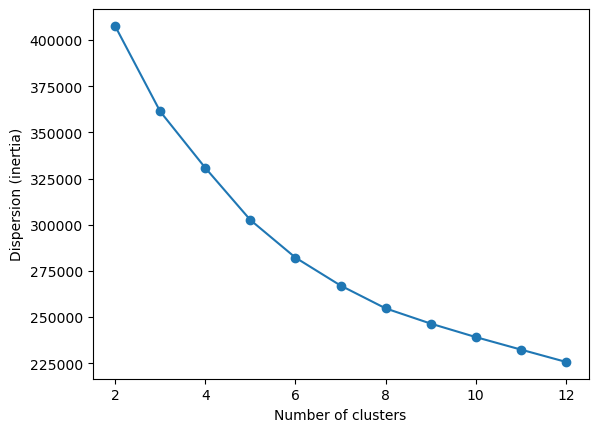

In [7]:
kmeans_workflow.find_optimal_k(X_scaled, K_range=12)

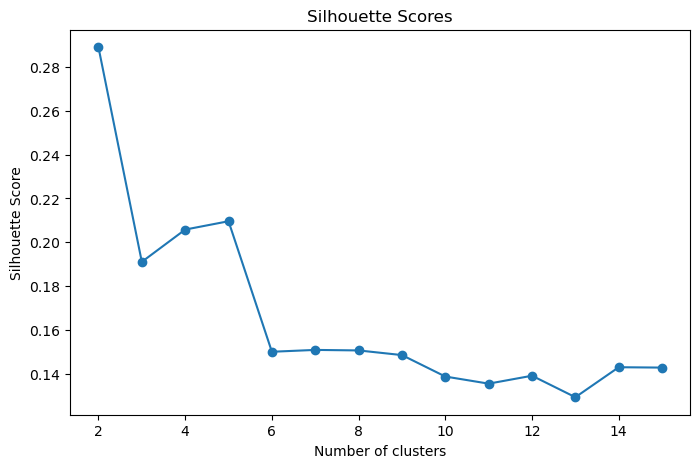

In [8]:
kmeans_workflow.silhouette(X_scaled, K_range=15)

In [9]:
kmeans = KMeans(n_clusters= 5,random_state=42, n_init=10)

kmeans_workflow = Clusteringworkflow(kmeans)
kmeans_workflow.fit_and_prediction(dataset, X_scaled)

dataset.head()


,customer_name,customer_gender,customer_age,education_level,kids_home,teens_home,total_children,has_children,year_first_transaction,distinct_stores_visited,...,share_electronics,share_vegetables,share_nonalcohol_drinks,share_alcohol_drinks,share_meat,share_fish,share_hygiene,share_videogames,share_petfood,cluster_kmeans
customer_id,,,,,,,,,,,,,,,,,,,,,
3,Crystal Kitchens,female,56,Bsc,1,1,2,1,2020,3,...,0.244917,0.020065,0.017375,0.009521,0.001506,0.011458,0.029693,0.013771,0.020656,4
4,Glenda Bauman,female,51,Bsc,1,0,1,1,2013,2,...,0.047596,0.099442,0.026343,0.004695,0.002125,0.000741,0.092918,0.016458,0.032867,0
5,Antonio Campbell,male,55,Msc,0,0,0,0,2005,2,...,0.000000,0.035694,0.006496,0.007589,0.081356,0.017557,0.032607,0.006496,0.014277,4
7,John Kelling,male,44,Unknown,0,0,0,0,2021,1,...,0.073903,0.005618,0.050629,0.075776,0.065008,0.072432,0.032437,0.110754,0.012306,2
8,Arthur Dematteo,male,57,Unknown,0,0,0,0,2021,1,...,0.420243,0.014730,0.022948,0.027833,0.041400,0.039346,0.011513,0.048765,0.017095,2


In [10]:
dataset["cluster_kmeans"].value_counts()

cluster_kmeans
4    17861
0     6031
2     3381
3     2782
1     2188
Name: count, dtype: int64

In [11]:
numeric_cols = dataset.select_dtypes(include='number').columns.drop('cluster_kmeans')

dataset.groupby("cluster_kmeans")[numeric_cols].mean().T

cluster_kmeans,0,1,2,3,4
customer_age,57.906317,58.086837,55.984620,57.540978,53.160013
kids_home,1.036644,0.853291,0.259391,3.280014,0.933318
teens_home,0.879622,0.759141,0.311742,2.724659,0.694250
total_children,1.916266,1.612431,0.571133,6.004673,1.627568
has_children,0.973636,0.871115,0.444839,1.000000,0.872851
year_first_transaction,2015.510032,2014.594607,2017.101154,2013.035945,2014.925312
distinct_stores_visited,3.410380,3.748629,1.514641,3.081237,3.329825
number_complaints,0.683303,0.975320,1.054422,0.985981,0.954258
typical_hour,12.323993,12.956124,17.412008,10.358375,12.256593
hour_sin,0.036813,-0.030832,-0.464903,0.378742,0.104488


In [12]:
X['cluster_kmeans'] = dataset['cluster_kmeans']

In [13]:
X.groupby("cluster_kmeans").mean().T

cluster_kmeans,0,1,2,3,4
customer_age,57.906317,58.086837,55.984620,57.540978,53.160013
kids_home,1.036644,0.853291,0.259391,3.280014,0.933318
teens_home,0.879622,0.759141,0.311742,2.724659,0.694250
distinct_stores_visited,3.410380,3.748629,1.514641,3.081237,3.329825
percentage_of_products_bought_promotion,0.131411,0.439866,0.261660,0.211972,0.401697
share_groceries,0.582246,0.405603,0.348806,0.649815,0.762007
share_vegetables,0.122143,0.053311,0.009594,0.022262,0.023339
share_meat,0.008134,0.098658,0.040267,0.041824,0.034079
share_fish,0.007141,0.070809,0.037685,0.036970,0.024820
share_electronics,0.096083,0.129853,0.392002,0.135312,0.061109


In [14]:
experimental_hierarchical = AgglomerativeClustering(n_clusters=None, distance_threshold=0, linkage="ward")

hierarchical_workflow = Clusteringworkflow(experimental_hierarchical)

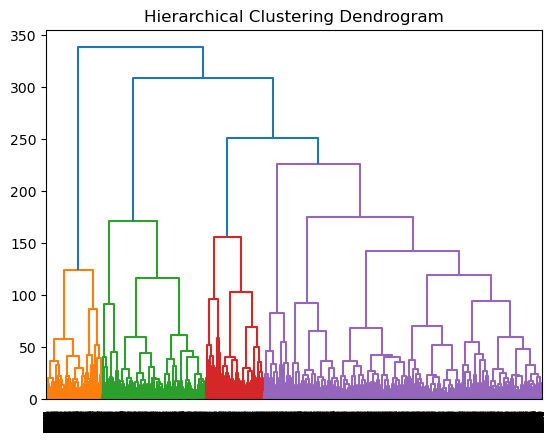

In [15]:
hierarchical_workflow.find_optimal_k(X_scaled)

In [ ]:
hierarchical_workflow.silhouette(X_scaled, K_range=10)

In [ ]:
hierarchical = AgglomerativeClustering(
    n_clusters=5,
    linkage="ward"
)

hierarchical_workflow = Clusteringworkflow(hierarchical)

hierarchical_workflow.fit_and_prediction(dataset, X_scaled)

dataset.head()

KeyboardInterrupt: 

#fazer comparação dos modelos... aquela matrix para comparar os clusters

In [ ]:
pca = PCA(n_components=2, random_state=42)

pca_workflow = PCAWorkflow(pca)
pca_workflow.fit_and_transformation(X_scaled)

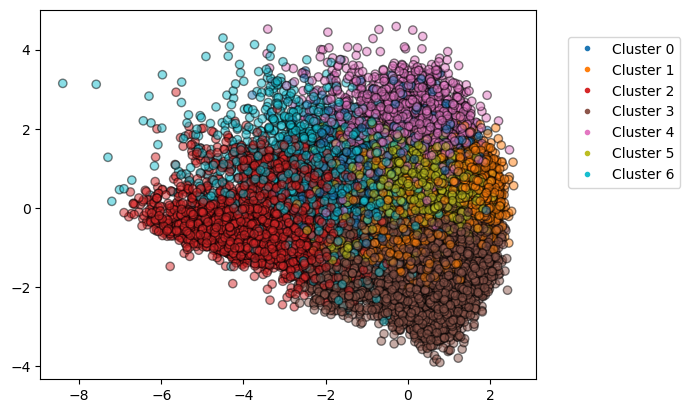

In [ ]:
pca_workflow.plot(dataset["cluster_kmeans"])

In [ ]:
tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate="auto",
    init="pca",
    random_state=42
)

tsne_workflow = TSNEWorkflow(tsne)
tsne_workflow.fit_and_transformation(X_scaled)

In [ ]:
tsne_workflow.plot(dataset["cluster_kmeans"])